<a href="https://colab.research.google.com/github/Ajaykakade24/PRODIGY_WD_02/blob/main/Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

ipl_df = pd.read_csv('/content/class_ipl_22-26_dataset.csv')

In [3]:
#Q1 the string trim trap

In [6]:
import pandas as pd

df = pd.DataFrame({'Score':[5,7,8,8,12,None,"8 "]})

df['Score'] = pd.to_numeric(
    df['Score'].astype(str).str.strip(),
    errors='coerce'
)

print(df)

   Score
0    5.0
1    7.0
2    8.0
3    8.0
4   12.0
5    NaN
6    8.0


In [ ]:
#Q2.the null imputation strategy

In [7]:
median_score = df['Score'].median()

df['Score'] = df['Score'].fillna(median_score)

print(df)

   Score
0    5.0
1    7.0
2    8.0
3    8.0
4   12.0
5    8.0
6    8.0


In [8]:
#3.the outlier boundary check (IQR method)
import numpy as np

Q1 = np.percentile(df['Score'],25)
Q3 = np.percentile(df['Score'],75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5*IQR

outliers = df[df['Score'] > upper_bound]

print("Q1 =",Q1)
print("Q3 =",Q3)
print("IQR =",IQR)
print("Upper Bound =",upper_bound)

print(outliers)

Q1 = 7.5
Q3 = 8.0
IQR = 0.5
Upper Bound = 8.75
   Score
4   12.0


In [9]:
#4.feature Engineering via vectorization

In [10]:
df['Hours_Studied'] = [2,3,4,4,5,3,4]

In [11]:
df['Efficiency_Score'] = np.where(
    df['Hours_Studied'] != 0,
    df['Score']/df['Hours_Studied'],
    0
)

print(df)

   Score  Hours_Studied  Efficiency_Score
0    5.0              2          2.500000
1    7.0              3          2.333333
2    8.0              4          2.000000
3    8.0              4          2.000000
4   12.0              5          2.400000
5    8.0              3          2.666667
6    8.0              4          2.000000


In [12]:
#Q5.The central balance point(mean vs median vs mode )

In [15]:
print("Mean =",np.mean(df['Score']))
print("Median =",np.median(df['Score']))

print('mode',df['Score'].mode(0))

Mean = 8.0
Median = 8.0
mode 0    8.0
Name: Score, dtype: float64


In [16]:
#6.the volatility scores(variance and standard deviation)

In [17]:
print("Variance =",
      np.var(df['Score'],ddof=0))

print("Standard Deviation =",
      np.std(df['Score'],ddof=0))

Variance = 3.7142857142857144
Standard Deviation = 1.927248223318863


In [18]:
#7.univariate shape : The skewness distribution


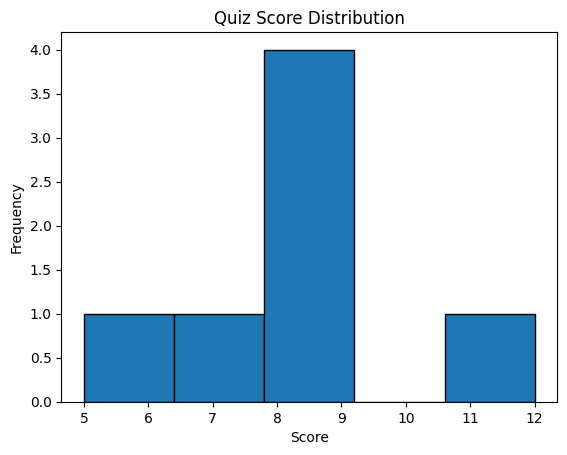

In [19]:
import matplotlib.pyplot as plt

plt.hist(
    df['Score'],
    bins=5,
    edgecolor='black'
)

plt.title("Quiz Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.show()

In [20]:
#8.Univariate spread: The density boxplot

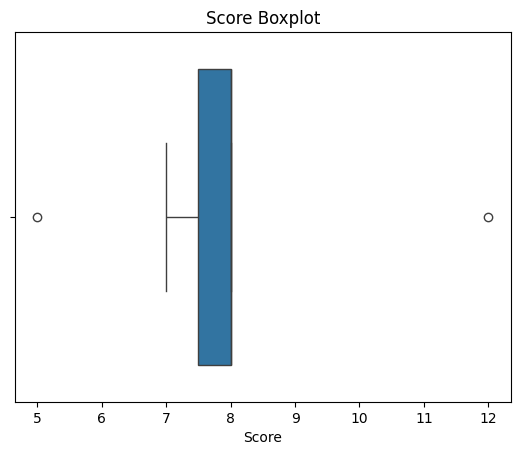

In [21]:
import seaborn as sns

sns.boxplot(x=df['Score'])

plt.title("Score Boxplot")
plt.show()

In [22]:
# 9.Bivariate Coordination : the scalar quadrant

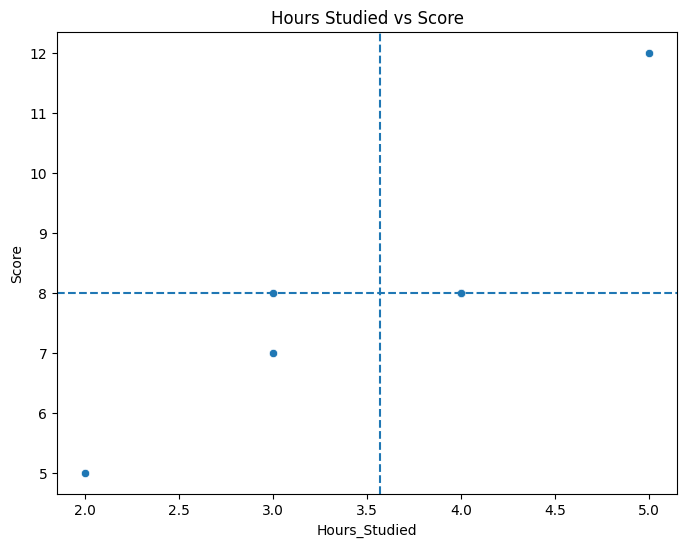

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Hours_Studied',
    y='Score',
    data=df
)

plt.axvline(
    df['Hours_Studied'].mean(),
    linestyle='--'
)

plt.axhline(
    df['Score'].mean(),
    linestyle='--'
)

plt.title("Hours Studied vs Score")

plt.show()

In [27]:
# 10.Muiltivariate matrices:correltion Heatmaps and Faceted Grids

In [28]:
df['Passed_Exam'] = np.where(
    df['Score'] >= 8,
    'Pass',
    'Fail'
)

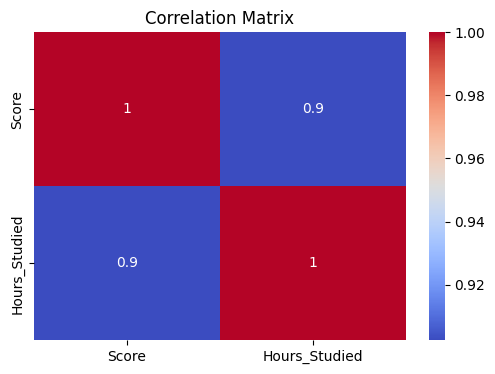

In [29]:
corr = df[['Score','Hours_Studied']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

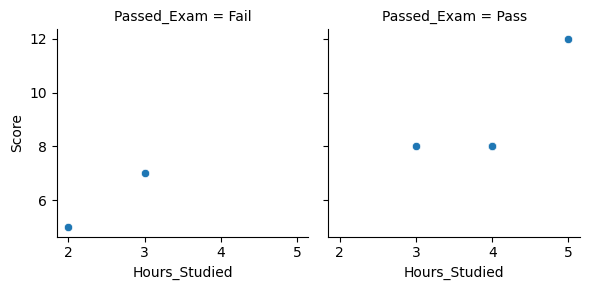

In [30]:
g = sns.FacetGrid(
    df,
    col='Passed_Exam'
)

g.map_dataframe(
    sns.scatterplot,
    x='Hours_Studied',
    y='Score'
)

plt.show()